<a href="https://colab.research.google.com/github/celinekm/CN/blob/main/atv3_celine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Nome: Celine Kazumi Miyajima RA: 176209**

             TABELA DE RESULTADOS                 


Função,Método,Valores Iniciais,Raiz Aproximada,|f(x)| final,Iterações / Resultado
f1(x) = x² - 2,Bisseção,"[1.0, 2.0]",1.4142137,2.69e-07,21 (Convergido)
f1(x) = x² - 2,Newton,1.5,1.4142136,4.44e-16,4 (Convergido)
f1(x) = x² - 2,Secante,"(1.0, 2.0)",1.4142136,8.88e-16,6 (Convergido)
f2(x) = x³ - x - 2,Bisseção,"[1.0, 2.0]",1.5213797,1.45e-08,22 (Convergido)
f2(x) = x³ - x - 2,Newton,1.5,1.5213797,4.53e-14,3 (Convergido)
f2(x) = x³ - x - 2,Secante,"(1.0, 2.0)",1.5213797,1.84e-14,7 (Convergido)
f3(x) = e^(-x) - x,Bisseção,"[0.0, 1.0]",0.5671434,2.35e-07,20 (Convergido)
f3(x) = e^(-x) - x,Newton,0.5,0.5671433,4.44e-15,3 (Convergido)
f3(x) = e^(-x) - x,Secante,"(0.0, 1.0)",0.5671433,1.24e-13,5 (Convergido)
f4(x) = x³ - 2x + 2,Bisseção,"[-2.0, -1.0]",-1.7692924,2.55e-09,21 (Convergido)



Gerando arquivos de animação...

             EXIBIÇÃO DAS ANIMAÇÕES (GIF)         

1. Animação - Método da Bisseção em f1(x)


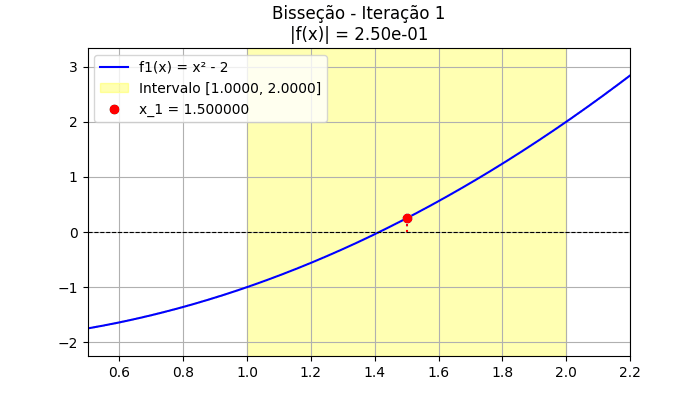


2. Animação - Método de Newton em f3(x)


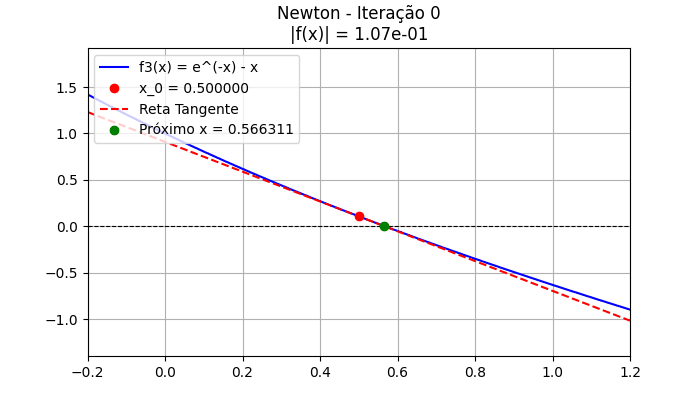


3. Animação - Método da Secante em f2(x)


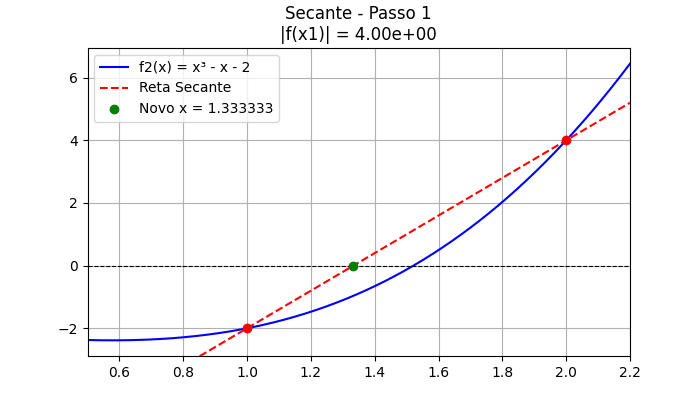

In [2]:
!pip install -q matplotlib pandas numpy pillow

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.animation import PillowWriter
import pandas as pd
from IPython.display import display, HTML, Image

# ==========================================
# PARTE 1: IMPLEMENTAÇÃO DOS MÉTODOS NUMÉRICOS
# ==========================================

# Critério de Parada Adotado:
# Adotou-se o critério combinado: a iteração para quando |x_{k+1} - x_k| < tol
# E |f(x_{k+1})| < tol, garantindo proximidade do ponto e resíduo pequeno.

def bissecao(f, a, b, tol=1e-6, max_iter=100):
    if f(a) * f(b) > 0:
        return None, 0, [], "Falha: f(a)*f(b) > 0 (Sem garantia de raiz no intervalo)"

    historico = []
    a_curr, b_curr = float(a), float(b)

    for k in range(max_iter):
        x_k = (a_curr + b_curr) / 2.0
        historico.append((a_curr, b_curr, x_k))

        if abs(f(x_k)) < tol and (b_curr - a_curr) / 2.0 < tol:
            return x_k, k + 1, historico, "Convergido"

        if f(a_curr) * f(x_k) < 0:
            b_curr = x_k
        else:
            a_curr = x_k

    return x_k, max_iter, historico, "Falha: Número máximo de iterações atingido"

def newton(f, df, x0, tol=1e-6, max_iter=100):
    historico = [float(x0)]
    xk = float(x0)

    for k in range(max_iter):
        df_val = df(xk)
        if abs(df_val) < 1e-12:
            return xk, k, historico, "Falha: Derivada muito próxima de zero"

        xk_next = xk - f(xk) / df_val
        historico.append(xk_next)

        if abs(xk_next - xk) < tol and abs(f(xk_next)) < tol:
            return xk_next, k + 1, historico, "Convergido"

        xk = xk_next

    return xk, max_iter, historico, "Falha: Número máximo de iterações atingido"

def secante(f, x0, x1, tol=1e-6, max_iter=100):
    historico = [float(x0), float(x1)]
    x0_c, x1_c = float(x0), float(x1)

    for k in range(max_iter):
        f_x0 = f(x0_c)
        f_x1 = f(x1_c)
        den = f_x1 - f_x0

        if abs(den) < 1e-12:
            return x1_c, k, historico, "Falha: Denominador muito próximo de zero"

        x2 = x1_c - f_x1 * (x1_c - x0_c) / den
        historico.append(x2)

        if abs(x2 - x1_c) < tol and abs(f(x2)) < tol:
            return x2, k + 1, historico, "Convergido"

        x0_c = x1_c
        x1_c = x2

    return x1_c, max_iter, historico, "Falha: Número máximo de iterações atingido"


# ==========================================
# PARTE 2: APLICAÇÃO E TABELA DE RESULTADOS
# ==========================================

funcoes = [
    {
        'nome': 'f1(x) = x² - 2',
        'f': lambda x: x**2 - 2,
        'df': lambda x: 2*x,
        'bis_i': [1.0, 2.0], 'new_i': 1.5, 'sec_i': (1.0, 2.0),
        'dom': (0.5, 2.2)
    },
    {
        'nome': 'f2(x) = x³ - x - 2',
        'f': lambda x: x**3 - x - 2,
        'df': lambda x: 3*x**2 - 1,
        'bis_i': [1.0, 2.0], 'new_i': 1.5, 'sec_i': (1.0, 2.0),
        'dom': (0.5, 2.2)
    },
    {
        'nome': 'f3(x) = e^(-x) - x',
        'f': lambda x: np.exp(-x) - x,
        'df': lambda x: -np.exp(-x) - 1,
        'bis_i': [0.0, 1.0], 'new_i': 0.5, 'sec_i': (0.0, 1.0),
        'dom': (-0.2, 1.2)
    },
    {
        'nome': 'f4(x) = x³ - 2x + 2',
        'f': lambda x: x**3 - 2*x + 2,
        'df': lambda x: 3*x**2 - 2,
        'bis_i': [-2.0, -1.0], 'new_i': -2.0, 'sec_i': (-2.0, -1.0),
        'dom': (-2.3, -0.7)
    }
]

resultados = []

for item in funcoes:
    f, df = item['f'], item['df']

    # Bisseção
    r, it, hist, res = bissecao(f, item['bis_i'][0], item['bis_i'][1])
    resultados.append({
        'Função': item['nome'], 'Método': 'Bisseção',
        'Valores Iniciais': str(item['bis_i']),
        'Raiz Aproximada': f"{r:.7f}" if r is not None else "N/A",
        '|f(x)| final': f"{abs(f(r)):.2e}" if r is not None else "N/A",
        'Iterações / Resultado': f"{it} ({res})"
    })

    # Newton
    r, it, hist, res = newton(f, df, item['new_i'])
    resultados.append({
        'Função': item['nome'], 'Método': 'Newton',
        'Valores Iniciais': str(item['new_i']),
        'Raiz Aproximada': f"{r:.7f}" if r is not None else "N/A",
        '|f(x)| final': f"{abs(f(r)):.2e}" if r is not None else "N/A",
        'Iterações / Resultado': f"{it} ({res})"
    })

    # Secante
    r, it, hist, res = secante(f, item['sec_i'][0], item['sec_i'][1])
    resultados.append({
        'Função': item['nome'], 'Método': 'Secante',
        'Valores Iniciais': str(item['sec_i']),
        'Raiz Aproximada': f"{r:.7f}" if r is not None else "N/A",
        '|f(x)| final': f"{abs(f(r)):.2e}" if r is not None else "N/A",
        'Iterações / Resultado': f"{it} ({res})"
    })

df_res = pd.DataFrame(resultados)

print("==================================================")
print("             TABELA DE RESULTADOS                 ")
print("==================================================")
display(HTML(df_res.to_html(index=False)))


# ==========================================
# PARTE 3: GERADOR DE ANIMAÇÕES GIF
# ==========================================

def gerar_gif_bissecao(item, filename="bissecao.gif"):
    f = item['f']
    _, _, hist, _ = bissecao(f, item['bis_i'][0], item['bis_i'][1])

    fig, ax = plt.subplots(figsize=(7, 4))
    x_vals = np.linspace(item['dom'][0], item['dom'][1], 400)
    y_vals = f(x_vals)

    def update(frame):
        ax.clear()
        a, b, xk = hist[frame]
        ax.plot(x_vals, y_vals, 'b-', label=item['nome'])
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--')

        ax.axvspan(a, b, color='yellow', alpha=0.3, label=f'Intervalo [{a:.4f}, {b:.4f}]')
        ax.plot(xk, f(xk), 'ro', label=f'x_{frame+1} = {xk:.6f}')
        ax.vlines(xk, 0, f(xk), color='red', linestyle=':')

        ax.set_xlim(item['dom'][0], item['dom'][1])
        ax.set_ylim(min(y_vals) - 0.5, max(y_vals) + 0.5)
        ax.set_title(f"Bisseção - Iteração {frame+1}\n|f(x)| = {abs(f(xk)):.2e}")
        ax.legend(loc='upper left')
        ax.grid(True)

    anim = animation.FuncAnimation(fig, update, frames=len(hist), interval=800)
    anim.save(filename, writer=PillowWriter(fps=1))
    plt.close(fig)

def gerar_gif_newton(item, filename="newton.gif"):
    f, df = item['f'], item['df']
    _, _, hist, _ = newton(f, df, item['new_i'])

    fig, ax = plt.subplots(figsize=(7, 4))
    x_vals = np.linspace(item['dom'][0], item['dom'][1], 400)
    y_vals = f(x_vals)

    def update(frame):
        ax.clear()
        xk = hist[frame]
        ax.plot(x_vals, y_vals, 'b-', label=item['nome'])
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--')

        ax.plot(xk, f(xk), 'ro', label=f'x_{frame} = {xk:.6f}')

        if frame < len(hist) - 1:
            tangent_x = np.linspace(item['dom'][0], item['dom'][1], 100)
            tangent_y = f(xk) + df(xk) * (tangent_x - xk)
            ax.plot(tangent_x, tangent_y, 'r--', label='Reta Tangente')
            ax.plot(hist[frame+1], 0, 'go', label=f'Próximo x = {hist[frame+1]:.6f}')

        ax.set_xlim(item['dom'][0], item['dom'][1])
        ax.set_ylim(min(y_vals) - 0.5, max(y_vals) + 0.5)
        ax.set_title(f"Newton - Iteração {frame}\n|f(x)| = {abs(f(xk)):.2e}")
        ax.legend(loc='upper left')
        ax.grid(True)

    anim = animation.FuncAnimation(fig, update, frames=len(hist), interval=1000)
    anim.save(filename, writer=PillowWriter(fps=1))
    plt.close(fig)

def gerar_gif_secante(item, filename="secante.gif"):
    f = item['f']
    _, _, hist, _ = secante(f, item['sec_i'][0], item['sec_i'][1])

    fig, ax = plt.subplots(figsize=(7, 4))
    x_vals = np.linspace(item['dom'][0], item['dom'][1], 400)
    y_vals = f(x_vals)

    def update(frame):
        ax.clear()
        ax.plot(x_vals, y_vals, 'b-', label=item['nome'])
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--')

        x0, x1 = hist[frame], hist[frame+1]
        ax.plot([x0, x1], [f(x0), f(x1)], 'ro')

        m = (f(x1) - f(x0)) / (x1 - x0) if (x1 - x0) != 0 else 0
        sec_x = np.linspace(item['dom'][0], item['dom'][1], 100)
        sec_y = f(x1) + m * (sec_x - x1)
        ax.plot(sec_x, sec_y, 'r--', label='Reta Secante')

        if frame + 2 < len(hist):
            ax.plot(hist[frame+2], 0, 'go', label=f'Novo x = {hist[frame+2]:.6f}')

        ax.set_xlim(item['dom'][0], item['dom'][1])
        ax.set_ylim(min(y_vals) - 0.5, max(y_vals) + 0.5)
        ax.set_title(f"Secante - Passo {frame+1}\n|f(x1)| = {abs(f(x1)):.2e}")
        ax.legend(loc='upper left')
        ax.grid(True)

    anim = animation.FuncAnimation(fig, update, frames=len(hist)-1, interval=1000)
    anim.save(filename, writer=PillowWriter(fps=1))
    plt.close(fig)

# Gerando e exibindo os GIFs
print("\nGerando arquivos de animação...")
gerar_gif_bissecao(funcoes[0], "bissecao_f1.gif")
gerar_gif_newton(funcoes[2], "newton_f3.gif")
gerar_gif_secante(funcoes[1], "secante_f2.gif")

print("\n==================================================")
print("             EXIBIÇÃO DAS ANIMAÇÕES (GIF)         ")
print("==================================================")

print("\n1. Animação - Método da Bisseção em f1(x)")
display(Image(filename="bissecao_f1.gif"))

print("\n2. Animação - Método de Newton em f3(x)")
display(Image(filename="newton_f3.gif"))

print("\n3. Animação - Método da Secante em f2(x)")
display(Image(filename="secante_f2.gif"))